In [1]:
import os
import json
import torch
import argparse
import numpy as np
import difflib
import networkx as nx
import re
import matplotlib.pyplot as plt
import sentencepiece as spm
from sklearn.metrics.pairwise import cosine_similarity
from dataset_multilingual import EurParallelDatasetBPE, collate_parallelBPE
from dataset import EurDataset, collate_data
from models.transceiver import DeepSC
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.preprocessing import normalize
import copy
from w3lib.html import remove_tags
from student import Student
from models.lora2 import (
    apply_lora_to_decoder, 
    # load_lora,
    load_language_adapter,
    load_language_adapter_auto
)
from utils.bpe_utils import (
    SeqtoTextBPE, 
    transmitter,
    show_sequence,
    greedy_decode, 
    beam_decode,
    text_to_indices_bpe,
    load_bpe,
)
from utils.model_utils import( 
    BleuScore, 
    Channels,
    load_teacher,
    load_student,
    snr_to_noise, 
    power_normalize,
    subsequent_mask,
    send_through_channel,
    normalize_text,
    text_to_indices
)

from metrics.metrics_bpe import DeepSCMetrics

/home/prinako/External/WorkSpace/PGCC/DeepSC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#### Interactive Demo 1 (DeepSC)

In [3]:
@torch.no_grad()
def interactive_demo(
    args, 
    net, 
    students, 
    text, 
    token_to_idx, 
    sp, 
    decoder, 
    device,
    snr,
    student_languages=None,
):
    print("\n" + "=" * 70)
    print("DeepSC BPE interactive mode")
    print("=" * 70)

    pad_idx = token_to_idx["<PAD>"]
    start_idx = token_to_idx["<START>"]
    end_idx = token_to_idx["<END>"]


    # Validate models/languages
    if student_languages is None:
        student_languages = ["<EN>"] * len(students)

    if len(student_languages) != len(students):
        raise ValueError(
            "student_languages must contain one language "
            "for each student model."
        )

    for language in student_languages:
        if language not in token_to_idx:
            raise ValueError(
                f"Language token {language!r} not found in vocabulary."
            )

    normalized, seq = text_to_indices_bpe(
        text,
        sp,
        token_to_idx,
        args.MAX_LENGTH,
        "<EN>",
    )

    src = torch.tensor([seq], dtype=torch.long, device=device)

    show_sequence("INPUT BPE", seq, sp, pad_idx)
    print("Decoded input:", decoder.sequence_to_text(seq))
    print("Input length :", len(seq))

    net.eval()
    for student in students:
        if student is not None:
            student.eval()
    
    src_mask = (src == pad_idx).unsqueeze(-2).type(torch.FloatTensor).to(device) #[batch, 1, seq_len]

    tx_data = transmitter(src,src_mask, net, pad_idx, device)
    print("\nTransmitting ...")
    print("Tx shape:", tuple(tx_data.shape))

    Rx_sig = send_through_channel(tx_data, args.channel, snr)

    teacher_out = greedy_decode(
        Rx_sig=Rx_sig,
        model=net,
        src=src,
        src_mask=src_mask,
        max_len=args.MAX_LENGTH,
        start_idx=start_idx,
        padding_idx=pad_idx,
        end_idx=end_idx,
        target_language_idx=token_to_idx["<EN>"],
        channel=args.channel,
        snr=snr,
        device=device,
    )

    students_out = []
    student_pt_out = None


    for student, language in zip(students, student_languages):
        if student is not None:
            # student_out = beam_decode(
            #     Rx_sig=Rx_sig,
            #     model=student,
            #     src=src,
            #     src_mask=src_mask,
            #     max_len=args.MAX_LENGTH,
            #     start_idx=start_idx,
            #     padding_idx=pad_idx,
            #     end_idx=end_idx,
            #     target_language_idx=token_to_idx[language],
            #     channel=args.channel,
            #     snr=snr,
            #     device=device,
            #     beam_size=9,
            #     length_penalty=0.7,
            # )

            student_out = greedy_decode(
                Rx_sig=Rx_sig,
                model=student,
                src=src,
                src_mask=src_mask,
                max_len=args.MAX_LENGTH,
                start_idx=start_idx,
                padding_idx=pad_idx,
                end_idx=end_idx,
                target_language_idx=token_to_idx[language],
                channel=args.channel,
                snr=snr,
                device=device,
            )

            students_out.append(student_out)

    # if students[0] is not None:
    #     student_en_out = student_decode(
    #         rx_sig,
    #         students[0],
    #         src,
    #         args.MAX_LENGTH,
    #         start_idx,
    #         token_to_idx["<EN>"],
    #         end_idx,
    #         pad_idx,
    #         device,
    #     )

    # if students[1] is not None:
    #     student_pt_out = student_decode(
    #         rx_sig,
    #         students[1],
    #         src,
    #         args.MAX_LENGTH,
    #         start_idx,
    #         token_to_idx["<EN>"],
    #         end_idx,
    #         pad_idx,
    #         device,
    #     )

    teacher_ids = teacher_out[0].cpu().tolist()
    teacher_text = decoder.sequence_to_text(teacher_ids)
    # show_sequence("TEACHER EN BPE", teacher_ids, sp, pad_idx)

    students_text = []
    # student_pt_text = None

    for student, lan in zip(students_out, student_languages):
        ids = student[0].cpu().tolist()
        text = decoder.sequence_to_text(ids)
        students_text.append(text)
        show_sequence(f"STUDENT {lan} BPE", ids, sp, pad_idx)

    # if student_en_out is not None:
    #     ids = student_en_out[0].cpu().tolist()
    #     student_en_text = decoder.sequence_to_text(ids)
    #     show_sequence("STUDENT EN BPE", ids, sp, pad_idx)

    # if student_pt_out is not None:
    #     ids = student_pt_out[0].cpu().tolist()
    #     student_pt_text = decoder.sequence_to_text(ids)
    #     show_sequence("STUDENT / LoRA PT BPE", ids, sp, pad_idx)

    print("\n" + "-" * 70)
    print("Original EN          :", normalized)
    print("Received Teacher EN  :", teacher_text)
    for student_text, language in zip(students_text, student_languages):
        print(f"Received Student {language}:", student_text)
    
    # if student_en_text is not None:
    #     print("Student EN Received :", student_en_text)
    # if student_pt_text is not None:
    #     print("LoRA / Student PT   :", student_pt_text)
    print("-" * 70)

    return normalized, teacher_text, students_text

#### Interactive Demo 2 (DeepSC)

In [4]:
def interactive_demo2(
    args,
    net,
    students,
    tokenizer_model,
    text,
    token_to_idx,
    start_idx,
    end_idx,
    pad_idx,
    device,
    snr_in=6.0,
    student_languages=None,
    debug_tokens=False,
):
    """
    Interactive DeepSC inference.

    Parameters
    ----------
    args :
        Configuration namespace. Must contain:
            args.channel
            args.MAX_LENGTH

    net :
        Teacher / base DeepSC model.

    students : list
        List of student or LoRA models.

    text : str
        Input sentence.

    token_to_idx : dict
        Vocabulary token -> index mapping.

    start_idx : int
        <START> token index.

    end_idx : int
        <END> token index.

    pad_idx : int
        <PAD> token index.

    device :
        torch device.

    snr_in : float
        SNR in dB.

    student_languages : list[str], optional
        Target language token for each student.

        Example:
            ["<EN>", "<PT>"]

        means:
            students[0] -> English
            students[1] -> Portuguese

    debug_tokens : bool
        Print raw generated token IDs/tokens.
    """

    print("\n" + "=" * 70)
    print("DeepSC Interactive Mode")
    print("=" * 70)

    # Validate models/languages
    if student_languages is None:
        student_languages = ["<EN>"] * len(students)

    if len(student_languages) != len(students):
        raise ValueError(
            "student_languages must contain one language "
            "for each student model."
        )

    for language in student_languages:
        if language not in token_to_idx:
            raise ValueError(
                f"Language token {language!r} not found in vocabulary."
            )

    # Initialize tokenizer
    sp = spm.SentencePieceProcessor(
        model_file=tokenizer_model
    )


    seq_to_text = SeqtoTextBPE(
        token_to_idx,
        end_idx,
        tokenizer_model=tokenizer_model,
    )

    idx_to_token = {
        idx: token
        for token, idx in token_to_idx.items()
    }
    
    # Normalize input
    text = normalize_text(
        text.lower().strip()
    )

    # SNR
    try:
        snr = float(snr_in)
    except (ValueError, TypeError):
        snr = 6.0

    noise_std = snr_to_noise(snr)
    channels = Channels()

    print(f"Channel : {args.channel}")
    print(f"SNR     : {snr:.2f} dB")

    # Convert input sentence to token IDs
    seq = text_to_indices(
        text=text,
        token_to_idx=token_to_idx,
        start_idx=start_idx,
        end_idx=end_idx,
        pad_idx=pad_idx,
        max_length=args.MAX_LENGTH,
    )

    src = torch.tensor(
        [seq],
        dtype=torch.long,
        device=device,
    )

    # Evaluation mode
    net.eval()

    for student in students:
        student.eval()

    # Transmission
    with torch.no_grad():

        Tx_sig = transmitter(
            src=src,
            model=net,
            padding_idx=pad_idx,
            device=device,
        )

        print("\nTransmitting ...")
        print("Tx shape:", Tx_sig.shape)

        # Channel
        if args.channel == "AWGN":

            Rx_sig = channels.AWGN(
                Tx_sig,
                noise_std,
            )

        elif args.channel == "Rayleigh":

            Rx_sig = channels.Rayleigh(
                Tx_sig,
                noise_std,
            )

        elif args.channel == "Rician":

            Rx_sig = channels.Rician(
                Tx_sig,
                noise_std,
            )

        else:
            raise ValueError(
                f"Unsupported channel: {args.channel}. "
                "Choose AWGN, Rayleigh, or Rician."
            )

        # Teacher
        #
        # Teacher reconstruction language = English
        teacher_out = receiver(
            Rx_sig=Rx_sig,
            model=net,
            src=src,
            max_len=args.MAX_LENGTH,
            start_symbol=start_idx,
            padding_idx=pad_idx,
            language_symbol=token_to_idx["<EN>"],
            end_symbol=end_idx,
            device=device,
        )

        # Students / LoRA adapters
        student_outputs = []
        
        lora_pt_beam = None

        for student_model, language in zip(
            students,
            student_languages,
        ):
            output = student_decode2(
                Rx_sig=Rx_sig,
                model=student_model,
                src=src,
                max_len=args.MAX_LENGTH,
                start_symbol=start_idx,
                language_symbol=token_to_idx[language],
                end_symbol=end_idx,
                padding_idx=pad_idx,
                device=device,
                idx_to_token=idx_to_token,
                debug= False,
                top_k= None if language == "<EN>" else 10,
            )
            if language == "<PT>":
                lora_pt_beam = student_beam_decode(
                    Rx_sig=Rx_sig,
                    model=student_model,
                    src=src,
                    max_len=args.MAX_LENGTH,
                    start_symbol=start_idx,
                    language_symbol=token_to_idx[language],
                    end_symbol=end_idx,
                    padding_idx=pad_idx,
                    device=device,
                    beam_size=5,
                    length_penalty=0.7,
                    idx_to_token=idx_to_token,
                    debug=False,
                )

            student_outputs.append(output)
       


    # Helper: tensor -> IDs -> text
    def decode_output(output):
        ids = output.detach().cpu().tolist()[0]

        decoded = seq_to_text.sequence_to_text(ids)

        decoded = (
            decoded
            .replace(" ,", ",")
            .replace(" .", ".")
            .replace(" !", "!")
            .replace(" ?", "?")
            .replace(" ;", ";")
            .replace(" :", ":")
        )

        return ids, decoded

    # Decode teacher
    teacher_ids, teacher_text = decode_output(
        teacher_out
    )

    # Decode students
    decoded_students = []

    for output in student_outputs:
        ids, decoded = decode_output(output)

        decoded_students.append(
            {
                "ids": ids,
                "text": decoded,
            }
        )

    # Clean original text
    original_text = (
        text
        .replace(" ,", ",")
        .replace(" .", ".")
        .replace(" !", "!")
        .replace(" ?", "?")
        .replace(" ;", ";")
        .replace(" :", ":")
    )

    # Debug raw tokens
    if debug_tokens:

        print("\n" + "-" * 70)
        print("RAW TOKEN DEBUG")
        print("-" * 70)

        print("\nInput IDs:")
        print(src[0].detach().cpu().tolist())

        print("\nInput tokens:")
        print([
            idx_to_token.get(int(idx), "<UNKNOWN>")
            for idx in src[0].detach().cpu().tolist()
        ])

        print("\nTeacher IDs:")
        print(teacher_ids)

        print("\nTeacher tokens:")
        print([
            idx_to_token.get(int(idx), "<UNKNOWN>")
            for idx in teacher_ids
        ])

        for i, result in enumerate(decoded_students):

            language = student_languages[i]

            print(
                f"\nStudent {i + 1} "
                f"target={language} IDs:"
            )
            print(result["ids"])

            print(
                f"Student {i + 1} "
                f"target={language} tokens:"
            )
            print([
                idx_to_token.get(
                    int(idx),
                    "<UNKNOWN>",
                )
                for idx in result["ids"]
            ])

    # Display results
    print("\nReceiving ...")
    print("-" * 70)

    print(
        f"{'Original EN':22s}: "
        f"{original_text}"
    )

    print(
        f"{'Teacher EN':22s}: "
        f"{teacher_text}"
    )

    for i, result in enumerate(decoded_students):

        language = student_languages[i]

        label = (
            f"Student {i + 1} "
            f"{language}"
        )

        print(
            f"{label:22s}: "
            f"{result['text']}"
        )

    print("-" * 70)

    
    greedy_ids = student_outputs[1][0].cpu().tolist()
    beam_ids = lora_pt_beam[0].cpu().tolist()

    greedy_text = seq_to_text.sequence_to_text(
        greedy_ids
    )

    beam_text = seq_to_text.sequence_to_text(
        beam_ids
    )

    greedy_text = (
        greedy_text
        .replace(" ,", ",")
        .replace(" .", ".")
    )

    beam_text = (
        beam_text
        .replace(" ,", ",")
        .replace(" .", ".")
    )

    print("\nLoRA PT Greedy :", greedy_text)
    print("LoRA PT Beam   :", beam_text)
    
    # Return structured results
    return {
        "original": original_text,

        "teacher": {
            "language": "<EN>",
            "text": teacher_text,
            "ids": teacher_ids,
        },

        "students": [
            {
                "student": i + 1,
                "language": student_languages[i],
                "text": result["text"],
                "ids": result["ids"],
            }
            for i, result in enumerate(decoded_students)
        ],

        "snr_db": snr,
        "channel": args.channel,
    }

### Main function loading models

In [5]:
def build_teacher(args, vocab_size, device):
    return DeepSC(
        args.num_layers,
        vocab_size,
        vocab_size,
        args.MAX_LENGTH,
        args.MAX_LENGTH,
        args.d_model,
        args.num_heads,
        args.dff,
        args.dropout,
    ).to(device)


In [6]:
def build_student(args, vocab_size, device):
    return Student(
        4,
        vocab_size,
        vocab_size,
        vocab_size,
        vocab_size,
        args.d_model,
        8,
        args.dff,
        args.dropout,
    ).to(device)

In [7]:
from types import SimpleNamespace

args = {
    "vocab_file": "data/train/europarl_bpe/2026-09-12/vocab_bpe.json",  # vocab-file",
    "tokenizer_model": "data/train/europarl_bpe/2026-09-12/tokenizer_bpe.model",  # tokenizer-model",
    "teacher_encoder": "results/base_model/2026-09-15/encoder_26.pth",  # teacher-encoder",
    "teacher_decoder": "results/base_model/2026-09-15/decoder_26.pth",  # teacher-decoder",
    "student_en": "results/student/2026-09-17/student_03.pth",  # student-en",
    "student_pt": "results/student/2026-08-12/student_03.pth",  # student-pt",
    "lora_adapter": "results/lora/en_pt/2026-09-12/student_adapter_en_pt_best_48.pth",  # lora-adapter",
    "channel": "Rayleigh",  # channel",
    "snr": 8,  # snr",
    "MAX_LENGTH": 67,  # MAX-LENGTH",
    "d_model": 128,  # d-model",
    "dff": 512,  # dff",
    "num_layers": 8,  # num-layers",
    "num_heads": 16,  # num-heads",
    "dropout": 0.1,  # dropout",
    "use_lora": False,  # use-lora",
    "lora_r": 8,  # lora-r",
    "lora_alpha": 16.0,  # lora-alpha",
    "lora_dropout": 0.05,  # lora-dropout",
    "lora_targets": "self_q,self_v,src_q,src_v",  # lora-targets",
}

args = SimpleNamespace(**args)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

token_to_idx, sp = load_bpe(args.vocab_file, args.tokenizer_model)
vocab_size = len(token_to_idx)

# if vocab_size != 32000:
#     print("[Warning] vocab size is", vocab_size, "instead of 32000")

decoder = SeqtoTextBPE(
    token_to_idx,
    token_to_idx["<END>"],
    tokenizer_model=args.tokenizer_model,
)

teacher = build_teacher(args, vocab_size, device)

if args.teacher_encoder and args.teacher_decoder:
    teacher = load_teacher(
        teacher,
        args.teacher_encoder,
        args.teacher_decoder,
        device,
    )
else:
    print("[Warning] Teacher checkpoint not supplied; random weights are being used.")


student_en = build_student(args, vocab_size, device)
student_en = load_student(student_en, args.student_en, device)


student_pt = copy.deepcopy(student_en)
# student_pt = load_student(student_en, args.student_en, device)
# if args.use_lora:
#     if apply_lora_to_decoder is None:
#         raise ImportError("Could not import apply_lora_to_decoder from models.lora2")

#     student_pt = apply_lora_to_decoder(
#         student_pt,
#         r=args.lora_r,
#         alpha=args.lora_alpha,
#         dropout=args.lora_dropout,
#         target_modules=tuple(args.lora_targets.split(",")),
#         verbose=True,
#     )

# if args.lora_adapter:
#     student_pt = load_language_adapter_auto(
#         student_pt,
#         args.lora_adapter,
#         device,
#         apply_lora_fn=apply_lora_to_decoder,
#     ).to(device)


Device: cuda:0
BPE CHECK
SentencePiece vocab : 96000
JSON vocab          : 96000
<PAD>    JSON=0     SP=0    
<START>  JSON=1     SP=1    
<END>    JSON=2     SP=2    
<UNK>    JSON=3     SP=3    
<EN>     JSON=4     SP=4    
<PT>     JSON=5     SP=5    
<ES>     JSON=6     SP=6    
<FR>     JSON=7     SP=7    
Teacher loaded
Student loaded: results/student/2026-09-17/student_03.pth


### Embeddings Visualization of Student

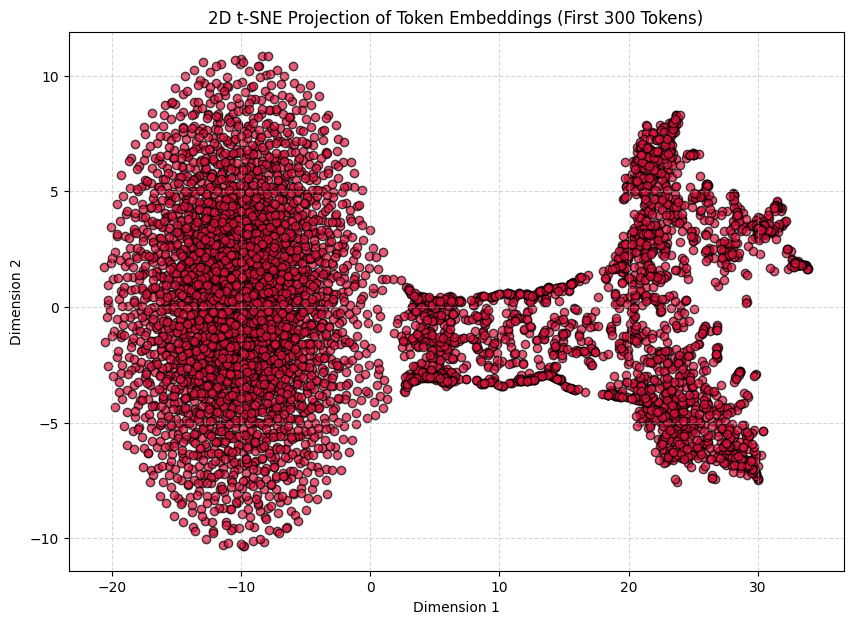

In [8]:
import matplotlib.pyplot as plt

# Optional: pip install scikit-learn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Take a sample of embeddings (e.g., 300 tokens) to reduce compute time
num_samples = 6327
embedding_matrix = student_en.decoder.embedding.weight.data
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# 2. Reduce 128 dimensions down to 2 dimensions using t-SNE (or PCA)
# For PCA: reducer = PCA(n_components=2)
reducer = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = reducer.fit_transform(sample_weights)

# 3. Plot the 2D projection
plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, c="crimson", edgecolors="k"
)

plt.title("2D t-SNE Projection of Token Embeddings (First 300 Tokens)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
# plt.savefig("embedding_tsne.png", dpi=300)
plt.show()

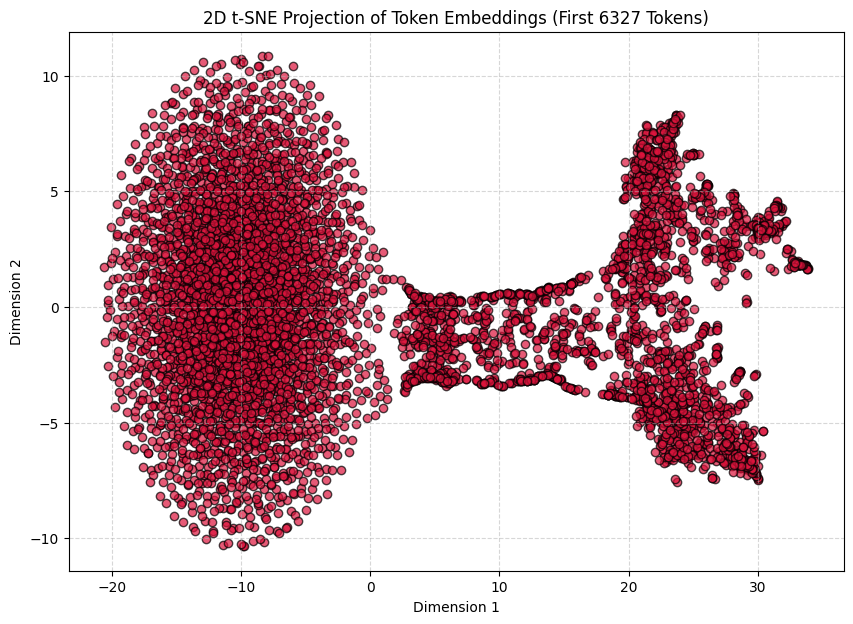

In [9]:
import matplotlib.pyplot as plt

# Optional: pip install scikit-learn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Take a sample of embeddings (e.g., 300 tokens) to reduce compute time
num_samples = 6327
embedding_matrix = student_pt.decoder.embedding.weight.data
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# 2. Reduce 128 dimensions down to 2 dimensions using t-SNE (or PCA)
# For PCA: reducer = PCA(n_components=2)
reducer = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = reducer.fit_transform(sample_weights)

# 3. Plot the 2D projection
plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, c="crimson", edgecolors="k"
)

plt.title(f"2D t-SNE Projection of Token Embeddings (First {num_samples} Tokens)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
# plt.savefig("embedding_tsne.png", dpi=300)
plt.show()

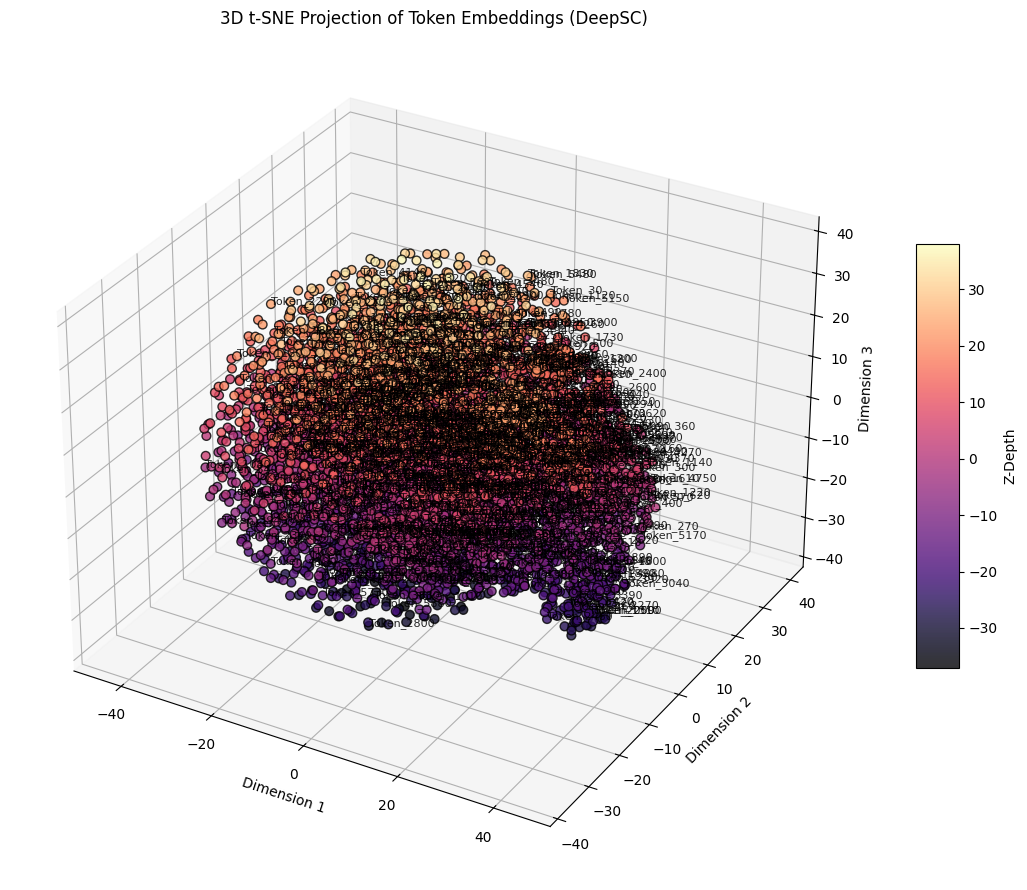

In [10]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Extract Embeddings & Map Vocab
# ---------------------------------------------------------
embedding_matrix = student_pt.decoder.embedding.weight.data
num_samples = 6327
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# Map token IDs to vocabulary words
labels = [
    id_to_word.get(i, f"T_{i}") if "id_to_word" in locals() else f"Token_{i}"
    for i in range(num_samples)
]

# ---------------------------------------------------------
# 2. Reduce Dimensions (128D -> 3D)
# ---------------------------------------------------------
from sklearn.manifold import TSNE

reducer = TSNE(n_components=3, perplexity=30, random_state=42, init="pca")
embeddings_3d = reducer.fit_transform(sample_weights)

# ---------------------------------------------------------
# 3. Plot in 3D using Matplotlib
# ---------------------------------------------------------
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Scatter points
sc = ax.scatter(
    embeddings_3d[:, 0],
    embeddings_3d[:, 1],
    embeddings_3d[:, 2],
    c=embeddings_3d[:, 2],  # Color by Z-axis depth
    cmap="magma",
    alpha=0.8,
    edgecolors="k",
    s=40,
)

# Annotate a subset of points (e.g., every 10th token to avoid clutter)
for i in range(0, num_samples, 10):
    ax.text(
        embeddings_3d[i, 0],
        embeddings_3d[i, 1],
        embeddings_3d[i, 2],
        labels[i],
        fontsize=8,
        alpha=0.85,
    )

ax.set_title("3D t-SNE Projection of Token Embeddings (DeepSC)")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label="Z-Depth")
plt.tight_layout()
plt.show()

In [11]:
# import json
# import matplotlib.pyplot as plt
# import plotly.express as px
# from sklearn.manifold import TSNE

# # ---------------------------------------------------------
# # 1. Load Vocabulary JSON File (Robust Parser)
# # ---------------------------------------------------------
# vocab_path = args.vocab_file  # Replace with your path

# with open(vocab_path, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# # Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
# if isinstance(vocab_data, dict):
#     if "token_to_idx" in vocab_data:
#         raw_vocab = vocab_data["token_to_idx"]
#     elif "idx_to_token" in vocab_data:
#         raw_vocab = vocab_data["idx_to_token"]
#     elif "vocab" in vocab_data:
#         raw_vocab = vocab_data["vocab"]
#     else:
#         raw_vocab = vocab_data
# else:
#     raw_vocab = vocab_data

# # Convert to {int_id: "word_string"}
# id_to_word = {}
# if isinstance(raw_vocab, dict):
#     for k, v in raw_vocab.items():
#         # Skip non-token metadata items if any exist
#         try:
#             if isinstance(v, int):
#                 id_to_word[v] = str(k)
#             elif str(k).isdigit():
#                 id_to_word[int(k)] = str(v)
#             else:
#                 # Fallback for key-value pairs where key is string integer
#                 id_to_word[int(v)] = str(k)
#         except (ValueError, TypeError):
#             continue
# elif isinstance(raw_vocab, list):
#     id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# # ---------------------------------------------------------
# # 2. Extract Embeddings & Map Word Labels
# # ---------------------------------------------------------
# embedding_matrix = student_pt.decoder.embedding.weight.data
# num_samples = 100 # Adjust sample size as needed
# sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# # Map token IDs to actual words, falling back to UNK_<id> if missing
# labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]

# # ---------------------------------------------------------
# # 3. Reduce Dimensions (128D -> 3D)
# # ---------------------------------------------------------
# reducer = TSNE(
#     n_components=3,
#     perplexity=min(30, num_samples - 1),
#     random_state=42,
#     init="pca",
# )
# embeddings_3d = reducer.fit_transform(sample_weights)

# # ---------------------------------------------------------
# # 4. Interactive 3D Plot with Plotly
# # ---------------------------------------------------------
# fig = px.scatter_3d(
#     x=embeddings_3d[:, 0],
#     y=embeddings_3d[:, 1],
#     z=embeddings_3d[:, 2],
#     hover_name=labels,  # Hover shows the exact token/word
#     text=labels,
#     title="DeepSC Embedding Space (3D t-SNE)",
#     labels={"x": "Dim 1", "y": "Dim 2", "z": "Dim 3"},
# )

# fig.update_traces(
#     marker=dict(size=4, color="crimson", line=dict(width=0.5, color="black")),
#     textposition="top center",
# )

# fig.update_layout(
#     scene=dict(
#         xaxis_title="Dimension 1",
#         yaxis_title="Dimension 2",
#         zaxis_title="Dimension 3",
#     ),
#     margin=dict(l=0, r=0, b=0, t=40),
# )

# fig.show(renderer="browser")

In [12]:
# import json
# import math
# import torch
# import pandas as pd
# import numpy as np
# import plotly.express as px
# import sentencepiece as spm

# from collections import Counter
# from sklearn.decomposition import PCA

# # Optional, but recommended for visualization
# try:
#     import umap
#     HAS_UMAP = True
# except ImportError:
#     HAS_UMAP = False


# # =========================================================
# # CONFIG
# # =========================================================

# VOCAB_PATH = args.vocab_file

# TOKENIZER_MODEL = (
#     "./data/train/europarl_bpe/tokenizer_bpe.model"
# )

# # Example raw corpora or decoded sentence lists.
# #
# # These should contain the actual EN and PT text used by your system.
# #
# # Replace these with your own lists.
# english_sentences = []
# portuguese_sentences = []

# # Models
# # student_en = ...
# # student_pt = ...  # PT LoRA-loaded student


# # =========================================================
# # LOAD VOCAB + TOKENIZER
# # =========================================================

# with open(VOCAB_PATH, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# token_to_idx = vocab_data["token_to_idx"]

# id_to_token = {
#     int(idx): token
#     for token, idx in token_to_idx.items()
# }

# sp = spm.SentencePieceProcessor(
#     model_file=TOKENIZER_MODEL
# )

# vocab_size = sp.get_piece_size()

# print("Vocabulary size:", vocab_size)


# # =========================================================
# # SPECIAL TOKENS
# # =========================================================

# SPECIAL_TOKENS = {
#     "<PAD>",
#     "<START>",
#     "<END>",
#     "<UNK>",
#     "<EN>",
#     "<PT>",
#     "<ES>",
#     "<FR>",
# }


# # =========================================================
# # PART 1
# # LANGUAGE-DOMINANT BPE EMBEDDING SPACE
# # =========================================================


# def count_bpe_tokens(
#     sentences,
#     tokenizer,
# ):
#     """
#     Count how often each SentencePiece ID appears.
#     """

#     counter = Counter()

#     for text in sentences:

#         ids = tokenizer.encode(
#             text,
#             out_type=int,
#         )

#         counter.update(ids)

#     return counter


# def classify_language_dominance(
#     token_id,
#     en_counts,
#     pt_counts,
#     threshold=2.0,
#     min_count=5,
# ):
#     """
#     Classify a token as:
#       - EN-dominant
#       - PT-dominant
#       - shared
#       - rare

#     threshold=2 means one language must occur at least
#     2x more often than the other.
#     """

#     en = en_counts.get(token_id, 0)
#     pt = pt_counts.get(token_id, 0)

#     total = en + pt

#     if total < min_count:
#         return "rare"

#     ratio = (en + 1) / (pt + 1)

#     if ratio >= threshold:
#         return "EN-dominant"

#     if ratio <= 1 / threshold:
#         return "PT-dominant"

#     return "shared"


# def build_embedding_dataframe(
#     embedding_matrix,
#     english_sentences,
#     portuguese_sentences,
#     method="umap",
# ):
#     """
#     Visualize the shared BPE embedding space.

#     embedding_matrix:
#         decoder embedding weight
#         shape [vocab_size, d_model]
#     """

#     embedding_matrix = (
#         embedding_matrix
#         .detach()
#         .float()
#         .cpu()
#         .numpy()
#     )

#     en_counts = count_bpe_tokens(
#         english_sentences,
#         sp,
#     )

#     pt_counts = count_bpe_tokens(
#         portuguese_sentences,
#         sp,
#     )

#     valid_ids = []
#     labels = []
#     language_classes = []
#     token_types = []

#     for token_id in range(vocab_size):

#         piece = sp.id_to_piece(token_id)

#         if piece in SPECIAL_TOKENS:
#             continue

#         valid_ids.append(token_id)

#         labels.append(piece)

#         language_classes.append(
#             classify_language_dominance(
#                 token_id,
#                 en_counts,
#                 pt_counts,
#             )
#         )

#         if piece.startswith("▁"):
#             token_types.append("word_start")
#         else:
#             token_types.append("subword")

#     matrix = embedding_matrix[valid_ids]

#     # -----------------------------------------------------
#     # Dimensional reduction
#     # -----------------------------------------------------

#     if method == "umap" and HAS_UMAP:

#         reducer = umap.UMAP(
#             n_components=2,
#             n_neighbors=30,
#             min_dist=0.1,
#             metric="cosine",
#             random_state=42,
#         )

#         coords = reducer.fit_transform(matrix)

#         method_name = "UMAP"

#     else:

#         print(
#             "UMAP unavailable or PCA selected. "
#             "Using PCA."
#         )

#         reducer = PCA(
#             n_components=2
#         )

#         coords = reducer.fit_transform(matrix)

#         method_name = "PCA"

#     df = pd.DataFrame(
#         {
#             "token_id": valid_ids,
#             "piece": labels,
#             "language": language_classes,
#             "token_type": token_types,
#             "x": coords[:, 0],
#             "y": coords[:, 1],
#         }
#     )

#     return df, method_name


# def plot_bpe_embedding_space(
#     embedding_matrix,
#     english_sentences,
#     portuguese_sentences,
# ):
#     """
#     Plot shared EN/PT BPE embedding space.
#     """

#     df, method_name = build_embedding_dataframe(
#         embedding_matrix,
#         english_sentences,
#         portuguese_sentences,
#         method="umap",
#     )

#     fig = px.scatter(
#         df,
#         x="x",
#         y="y",
#         color="language",
#         symbol="token_type",

#         hover_name="piece",

#         hover_data={
#             "token_id": True,
#             "language": True,
#             "token_type": True,
#             "x": ":.4f",
#             "y": ":.4f",
#         },

#         title=(
#             f"DeepSC Shared BPE Embedding Space "
#             f"({method_name})"
#         ),
#     )

#     fig.update_traces(
#         marker=dict(
#             size=4,
#             opacity=0.65,
#         )
#     )

#     fig.update_layout(
#         xaxis_title=f"{method_name} 1",
#         yaxis_title=f"{method_name} 2",
#         margin=dict(
#             l=40,
#             r=20,
#             b=40,
#             t=60,
#         ),
#     )

#     fig.show(
#         renderer="browser"
#     )

#     return df


# # =========================================================
# # NEAREST NEIGHBORS
# # =========================================================


# def nearest_bpe_tokens(
#     embedding_matrix,
#     query_piece,
#     top_k=10,
# ):
#     """
#     Find nearest BPE pieces using cosine similarity.
#     """

#     query_id = sp.piece_to_id(
#         query_piece
#     )

#     if query_id < 0:
#         raise ValueError(
#             f"Unknown BPE piece: {query_piece}"
#         )

#     embeddings = (
#         embedding_matrix
#         .detach()
#         .float()
#     )

#     embeddings = torch.nn.functional.normalize(
#         embeddings,
#         dim=1,
#     )

#     query = embeddings[
#         query_id
#     ].unsqueeze(0)

#     similarity = (
#         query @ embeddings.T
#     ).squeeze(0)

#     values, indices = torch.topk(
#         similarity,
#         k=top_k + 1,
#     )

#     rows = []

#     for sim, idx in zip(
#         values.tolist(),
#         indices.tolist(),
#     ):

#         if idx == query_id:
#             continue

#         rows.append(
#             {
#                 "token_id": idx,
#                 "piece": sp.id_to_piece(idx),
#                 "cosine_similarity": sim,
#             }
#         )

#         if len(rows) >= top_k:
#             break

#     return pd.DataFrame(rows)


# # =========================================================
# # PART 2
# # DECODER HIDDEN-STATE VISUALIZATION
# # =========================================================


# def collect_decoder_hidden_states(
#     transmitter,
#     receiver_model,
#     loader,
#     device,
#     pad_idx,
#     channel,
#     noise_std,
#     max_batches=50,
# ):
#     """
#     Collect decoder hidden states.

#     Assumes receiver_model returns:
#         logits,
#         channel_decoder_output,
#         decoder_output

#     decoder_output shape:
#         [batch, seq_len, d_model]
#     """

#     transmitter.eval()
#     receiver_model.eval()

#     hidden_states = []
#     token_ids = []

#     with torch.no_grad():

#         for batch_idx, (src, trg) in enumerate(loader):

#             if batch_idx >= max_batches:
#                 break

#             src = src.to(device)
#             trg = trg.to(device)

#             trg_inp = trg[:, :-1]
#             trg_real = trg[:, 1:]

#             src_mask, look_ahead_mask = create_masks(
#                 src,
#                 trg_inp,
#                 pad_idx,
#             )

#             _, _, _, z_noisy = transmitter(
#                 src,
#                 src_mask,
#                 channel,
#                 noise_std,
#             )

#             logits, ch_out, dec_out = receiver_model(
#                 z_noisy,
#                 trg_inp,
#                 look_ahead_mask,
#                 src_mask,
#             )

#             # dec_out:
#             # [B, L, d_model]

#             valid_mask = (
#                 trg_real != pad_idx
#             )

#             valid_hidden = dec_out[
#                 valid_mask
#             ]

#             valid_tokens = trg_real[
#                 valid_mask
#             ]

#             hidden_states.append(
#                 valid_hidden.detach().cpu()
#             )

#             token_ids.append(
#                 valid_tokens.detach().cpu()
#             )

#     hidden_states = torch.cat(
#         hidden_states,
#         dim=0,
#     )

#     token_ids = torch.cat(
#         token_ids,
#         dim=0,
#     )

#     return hidden_states, token_ids


# # =========================================================
# # COMPARE EN AND PT HIDDEN STATES
# # =========================================================


# def compare_hidden_spaces(
#     en_hidden,
#     en_tokens,
#     pt_hidden,
#     pt_tokens,
#     method="umap",
#     max_points=15000,
# ):
#     """
#     Compare hidden-state geometry of:
#       - EN receiver
#       - PT-LoRA receiver
#     """

#     # -----------------------------------------------------
#     # Sample points to keep UMAP/Plotly manageable
#     # -----------------------------------------------------

#     if en_hidden.size(0) > max_points:

#         idx = torch.randperm(
#             en_hidden.size(0)
#         )[:max_points]

#         en_hidden = en_hidden[idx]
#         en_tokens = en_tokens[idx]

#     if pt_hidden.size(0) > max_points:

#         idx = torch.randperm(
#             pt_hidden.size(0)
#         )[:max_points]

#         pt_hidden = pt_hidden[idx]
#         pt_tokens = pt_tokens[idx]

#     en_np = en_hidden.numpy()
#     pt_np = pt_hidden.numpy()

#     all_hidden = np.concatenate(
#         [
#             en_np,
#             pt_np,
#         ],
#         axis=0,
#     )

#     # -----------------------------------------------------
#     # Reduction
#     # -----------------------------------------------------

#     if method == "umap" and HAS_UMAP:

#         reducer = umap.UMAP(
#             n_components=2,
#             n_neighbors=40,
#             min_dist=0.1,
#             metric="cosine",
#             random_state=42,
#         )

#         coords = reducer.fit_transform(
#             all_hidden
#         )

#         method_name = "UMAP"

#     else:

#         reducer = PCA(
#             n_components=2
#         )

#         coords = reducer.fit_transform(
#             all_hidden
#         )

#         method_name = "PCA"

#     n_en = len(en_np)

#     systems = (
#         ["Student EN"] * n_en
#         +
#         ["Student PT + LoRA"] * len(pt_np)
#     )

#     all_tokens = torch.cat(
#         [
#             en_tokens,
#             pt_tokens,
#         ]
#     ).tolist()

#     pieces = [
#         sp.id_to_piece(int(token_id))
#         for token_id in all_tokens
#     ]

#     df = pd.DataFrame(
#         {
#             "x": coords[:, 0],
#             "y": coords[:, 1],
#             "system": systems,
#             "token_id": all_tokens,
#             "piece": pieces,
#         }
#     )

#     fig = px.scatter(
#         df,

#         x="x",
#         y="y",

#         color="system",

#         hover_name="piece",

#         hover_data={
#             "token_id": True,
#             "system": True,
#             "x": ":.4f",
#             "y": ":.4f",
#         },

#         title=(
#             "DeepSC Decoder Hidden-State Space "
#             f"({method_name})"
#         ),
#     )

#     fig.update_traces(
#         marker=dict(
#             size=3,
#             opacity=0.4,
#         )
#     )

#     fig.update_layout(
#         xaxis_title=f"{method_name} 1",
#         yaxis_title=f"{method_name} 2",
#     )

#     fig.show(
#         renderer="browser"
#     )

#     return df


# # =========================================================
# # EXAMPLE USAGE
# # =========================================================


# # ---------------------------------------------------------
# # A. Shared BPE embedding
# # ---------------------------------------------------------

# embedding_df = plot_bpe_embedding_space(
#     embedding_matrix=(
#         student_en.decoder.embedding.weight
#     ),

#     english_sentences=english_sentences,

#     portuguese_sentences=portuguese_sentences,
# )


# # ---------------------------------------------------------
# # B. Nearest neighbors
# # ---------------------------------------------------------

# print("\nNearest to ▁union")

# print(
#     nearest_bpe_tokens(
#         student_en.decoder.embedding.weight,
#         "▁union",
#         top_k=10,
#     )
# )

# print("\nNearest to ▁união")

# print(
#     nearest_bpe_tokens(
#         student_en.decoder.embedding.weight,
#         "▁união",
#         top_k=10,
#     )
# )


# # ---------------------------------------------------------
# # C. Hidden-state comparison
# # ---------------------------------------------------------
# #
# # You need an EN validation loader and a PT validation loader.
# #
# # Example:
# #
# # en_hidden, en_tokens = collect_decoder_hidden_states(
# #     transmitter=transmitter,
# #     receiver_model=student_en,
# #     loader=en_val_loader,
# #     device=device,
# #     pad_idx=pad_idx,
# #     channel="Rayleigh",
# #     noise_std=SNR_to_noise(8),
# # )
# #
# # pt_hidden, pt_tokens = collect_decoder_hidden_states(
# #     transmitter=transmitter,
# #     receiver_model=student_pt,
# #     loader=pt_val_loader,
# #     device=device,
# #     pad_idx=pad_idx,
# #     channel="Rayleigh",
# #     noise_std=SNR_to_noise(8),
# # )
# #
# # hidden_df = compare_hidden_spaces(
# #     en_hidden,
# #     en_tokens,
# #     pt_hidden,
# #     pt_tokens,
# # )

In [13]:
# import json
# import torch
# import plotly.express as px
# import pandas as pd
# import sentencepiece as spm


# # =========================================================
# # CONFIG
# # =========================================================

# vocab_path = args.vocab_file

# tokenizer_path = (
#     "./data/train/europarl_bpe/tokenizer_bpe.model"
# )

# # Choose which model embedding to inspect
# embedding_matrix = (
#     student_en.decoder.embedding.weight.detach()
# )

# # How many PCA components to estimate.
# # We use more than 3 so variance estimates are more meaningful.
# PCA_Q = 32


# # =========================================================
# # 1. LOAD BPE VOCAB + SENTENCEPIECE TOKENIZER
# # =========================================================

# with open(vocab_path, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# if "token_to_idx" not in vocab_data:
#     raise KeyError(
#         "Expected key 'token_to_idx' in vocab JSON."
#     )

# token_to_idx = vocab_data["token_to_idx"]

# id_to_token = {
#     int(idx): token
#     for token, idx in token_to_idx.items()
# }

# sp = spm.SentencePieceProcessor(
#     model_file=tokenizer_path
# )


# # =========================================================
# # 2. CHECK VOCABULARY CONSISTENCY
# # =========================================================

# vocab_size = embedding_matrix.size(0)
# embedding_dim = embedding_matrix.size(1)

# print("=" * 70)
# print("BPE EMBEDDING INFORMATION")
# print("=" * 70)

# print(f"Embedding shape       : {tuple(embedding_matrix.shape)}")
# print(f"Embedding vocab size  : {vocab_size}")
# print(f"Embedding dimension   : {embedding_dim}")
# print(f"JSON vocab size       : {len(token_to_idx)}")
# print(f"SentencePiece size    : {sp.get_piece_size()}")

# assert vocab_size == len(token_to_idx), (
#     f"Embedding vocab size ({vocab_size}) "
#     f"!= JSON vocab size ({len(token_to_idx)})"
# )

# assert vocab_size == sp.get_piece_size(), (
#     f"Embedding vocab size ({vocab_size}) "
#     f"!= SentencePiece vocab size "
#     f"({sp.get_piece_size()})"
# )


# # =========================================================
# # 3. SPECIAL TOKENS
# # =========================================================

# SPECIAL_TOKENS = {
#     "<PAD>",
#     "<START>",
#     "<END>",
#     "<UNK>",
#     "<EN>",
#     "<PT>",
#     "<ES>",
#     "<FR>",
# }


# # =========================================================
# # 4. CLASSIFY BPE TOKEN TYPE
# # =========================================================

# def classify_token(piece: str) -> str:

#     if piece in SPECIAL_TOKENS:
#         return "special"

#     # punctuation / symbols
#     stripped = piece.replace("▁", "")

#     if stripped and all(
#         not ch.isalnum()
#         for ch in stripped
#     ):
#         return "punctuation"

#     # token starts a new word in SentencePiece
#     if piece.startswith("▁"):
#         return "word_start"

#     # continuation subword
#     return "subword"


# # =========================================================
# # 5. BUILD TOKEN METADATA
# # =========================================================

# records = []

# for token_id in range(vocab_size):

#     piece = id_to_token.get(
#         token_id,
#         sp.id_to_piece(token_id),
#     )

#     category = classify_token(piece)

#     readable_piece = piece.replace(
#         "▁",
#         "▁ ",
#     )

#     records.append(
#         {
#             "token_id": token_id,
#             "piece": piece,
#             "readable_piece": readable_piece,
#             "category": category,
#         }
#     )

# metadata_df = pd.DataFrame(records)

# print("\nToken counts:")
# print(metadata_df["category"].value_counts())


# # =========================================================
# # 6. EXCLUDE SPECIAL TOKENS FROM PCA
# # =========================================================

# valid_mask = (
#     metadata_df["category"] != "special"
# )

# valid_ids = (
#     metadata_df.loc[
#         valid_mask,
#         "token_id"
#     ]
#     .astype(int)
#     .tolist()
# )

# valid_ids_tensor = torch.tensor(
#     valid_ids,
#     dtype=torch.long,
#     device=embedding_matrix.device,
# )

# weights = embedding_matrix[
#     valid_ids_tensor
# ]

# print("\nPCA tokens included :", weights.size(0))
# print("Special tokens excluded:",
#       vocab_size - weights.size(0))


# # =========================================================
# # 7. CENTER EMBEDDINGS
# # =========================================================

# embedding_mean = weights.mean(
#     dim=0,
#     keepdim=True,
# )

# weights_centered = (
#     weights - embedding_mean
# )


# # =========================================================
# # 8. PCA ON GPU
# # =========================================================

# q = min(
#     PCA_Q,
#     embedding_dim,
#     weights_centered.size(0),
# )

# print("\nRunning PCA...")
# print(f"PCA q = {q}")

# U, S, V = torch.pca_lowrank(
#     weights_centered,
#     q=q,
#     center=False,
# )

# # Project into first 3 PCs
# embeddings_3d_gpu = (
#     weights_centered
#     @ V[:, :3]
# )

# embeddings_3d = (
#     embeddings_3d_gpu
#     .float()
#     .cpu()
#     .numpy()
# )


# # =========================================================
# # 9. VARIANCE INFORMATION
# # =========================================================

# # Eigenvalue contribution from returned singular values
# variance = S.pow(2)

# variance_ratio_q = (
#     variance
#     / variance.sum()
# )

# print("\nApproximate variance ratios")
# print("-" * 40)

# for i in range(min(10, q)):
#     print(
#         f"PC{i + 1:02d}: "
#         f"{variance_ratio_q[i].item() * 100:.2f}%"
#     )

# first3_ratio = (
#     variance[:3].sum()
#     / variance.sum()
# )

# print(
#     f"\nVariance captured by first 3 "
#     f"of {q} estimated PCs: "
#     f"{first3_ratio.item() * 100:.2f}%"
# )


# # =========================================================
# # 10. BUILD PLOT DATAFRAME
# # =========================================================

# plot_df = (
#     metadata_df
#     .loc[valid_mask]
#     .copy()
#     .reset_index(drop=True)
# )

# plot_df["PC1"] = embeddings_3d[:, 0]
# plot_df["PC2"] = embeddings_3d[:, 1]
# plot_df["PC3"] = embeddings_3d[:, 2]

# plot_df["hover_label"] = (
#     "ID="
#     + plot_df["token_id"].astype(str)
#     + " | "
#     + plot_df["readable_piece"]
# )


# # =========================================================
# # 11. INTERACTIVE 3D PCA PLOT
# # =========================================================

# fig = px.scatter_3d(
#     plot_df,

#     x="PC1",
#     y="PC2",
#     z="PC3",

#     color="category",

#     hover_name="hover_label",

#     hover_data={
#         "token_id": True,
#         "piece": True,
#         "category": True,
#         "PC1": ":.4f",
#         "PC2": ":.4f",
#         "PC3": ":.4f",
#     },

#     title=(
#         "DeepSC BPE Decoder Embedding Space "
#         "(3D PCA, Special Tokens Excluded)"
#     ),

#     labels={
#         "PC1": "Principal Component 1",
#         "PC2": "Principal Component 2",
#         "PC3": "Principal Component 3",
#         "category": "Token Type",
#     },
# )


# # =========================================================
# # 12. PLOT STYLE
# # =========================================================

# fig.update_traces(
#     marker=dict(
#         size=2.2,
#         opacity=0.65,
#     )
# )

# fig.update_layout(
#     scene=dict(
#         xaxis_title="Principal Component 1",
#         yaxis_title="Principal Component 2",
#         zaxis_title="Principal Component 3",
#     ),

#     margin=dict(
#         l=0,
#         r=0,
#         b=0,
#         t=50,
#     ),

#     legend_title_text="BPE Token Type",
# )


# # =========================================================
# # 13. SHOW
# # =========================================================

# fig.show(
#     renderer="browser"
# )

In [14]:
# import json
# import torch
# import plotly.express as px

# # ---------------------------------------------------------
# # 1. Load Vocabulary JSON File (Robust Parser)
# # ---------------------------------------------------------
# vocab_path = args.vocab_file  # Replace with your path

# with open(vocab_path, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# # Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
# if isinstance(vocab_data, dict):
#     if "token_to_idx" in vocab_data:
#         raw_vocab = vocab_data["token_to_idx"]
#     elif "idx_to_token" in vocab_data:
#         raw_vocab = vocab_data["idx_to_token"]
#     elif "vocab" in vocab_data:
#         raw_vocab = vocab_data["vocab"]
#     else:
#         raw_vocab = vocab_data
# else:
#     raw_vocab = vocab_data

# # Convert to {int_id: "word_string"}
# id_to_word = {}
# if isinstance(raw_vocab, dict):
#     for k, v in raw_vocab.items():
#         try:
#             if isinstance(v, int):
#                 id_to_word[v] = str(k)
#             elif str(k).isdigit():
#                 id_to_word[int(k)] = str(v)
#             else:
#                 id_to_word[int(v)] = str(k)
#         except (ValueError, TypeError):
#             continue
# elif isinstance(raw_vocab, list):
#     id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# # ---------------------------------------------------------
# # 2. Extract Embeddings directly on GPU VRAM
# # ---------------------------------------------------------
# embedding_matrix = student_en.decoder.embedding.weight.data  # Tensor on GPU

# num_samples = 32000  # Full vocabulary size

# # Slice tensor on CUDA
# # sample_weights_gpu = embedding_matrix[:num_samples]  # Shape: (96327, 128)
# sample_weights_gpu = embedding_matrix  # Shape: (96327, 128)

# print(sample_weights_gpu.shape)

# # Map token IDs to actual words for hover inspection
# labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]
# print(labels)

# # ---------------------------------------------------------
# # 3. Reduce Dimensions on GPU (128D -> 3D) using PyTorch PCA
# # ---------------------------------------------------------
# # torch.pca_lowrank runs fast SVD decomposition directly on CUDA cores
# U, S, V = torch.pca_lowrank(sample_weights_gpu, q=3)

# # Project embeddings into 3D: (96327, 128) @ (128, 3) -> (96327, 3)
# embeddings_3d_gpu = torch.matmul(sample_weights_gpu, V[:, :3])
# print(embeddings_3d_gpu.shape)

# # Only transfer the final (96327, 3) coordinate matrix to CPU for plotting
# embeddings_3d = embeddings_3d_gpu.cpu().numpy()

# # ---------------------------------------------------------
# # 4. Interactive 3D Plot with Plotly WebGL
# # ---------------------------------------------------------
# fig = px.scatter_3d(
#     x=embeddings_3d[:, 0],
#     y=embeddings_3d[:, 1],
#     z=embeddings_3d[:, 2],
#     hover_name=labels,  # Hover to inspect exact token
#     title="DeepSC Embedding Space - Full Vocab (3D GPU PCA)",
#     labels={"x": "PC 1", "y": "PC 2", "z": "PC 3"},
# )

# # Render compact WebGL markers for smooth 96k point rendering
# fig.update_traces(
#     marker=dict(
#         size=1.5,
#         color=embeddings_3d[:, 2],
#         colorscale="Viridis",
#         opacity=0.7,
#     )
# )

# fig.update_layout(
#     scene=dict(
#         xaxis_title="Principal Component 1",
#         yaxis_title="Principal Component 2",
#         zaxis_title="Principal Component 3",
#     ),
#     margin=dict(l=0, r=0, b=0, t=40),
# )

# fig.show(renderer="browser")

### Embeddings Visualization of DeepSC 

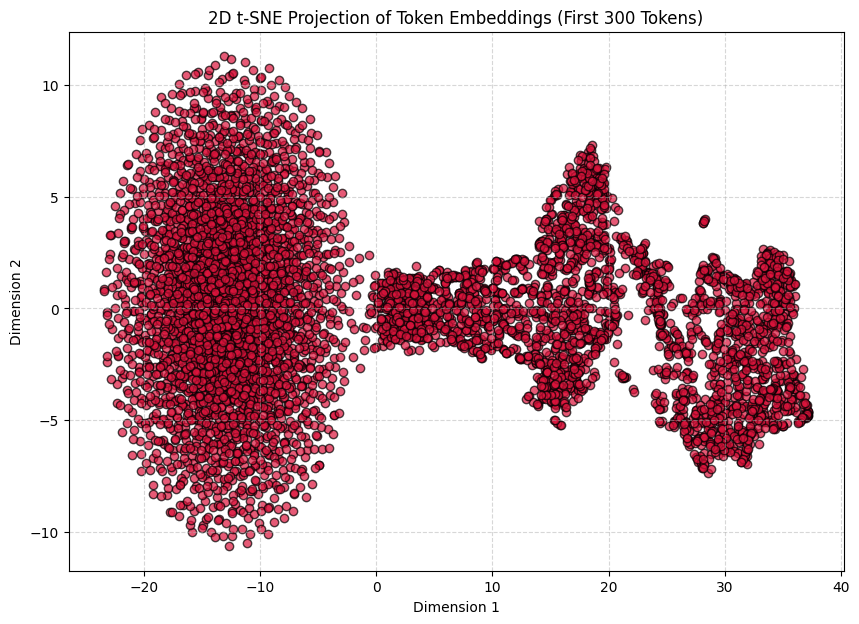

In [15]:
import matplotlib.pyplot as plt

# Optional: pip install scikit-learn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Take a sample of embeddings (e.g., 300 tokens) to reduce compute time
num_samples = 6327
embedding_matrix = teacher.encoder.embedding.weight.data
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# 2. Reduce 128 dimensions down to 2 dimensions using t-SNE (or PCA)
# For PCA: reducer = PCA(n_components=2)
reducer = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = reducer.fit_transform(sample_weights)

# 3. Plot the 2D projection
plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, c="crimson", edgecolors="k"
)

plt.title("2D t-SNE Projection of Token Embeddings (First 300 Tokens)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
# plt.savefig("embedding_tsne.png", dpi=300)
plt.show()

In [16]:
# import matplotlib.pyplot as plt

# # ---------------------------------------------------------
# # 1. Extract Embeddings & Map Vocab
# # ---------------------------------------------------------
# embedding_matrix = teacher.encoder.embedding.weight.data
# num_samples = 300
# sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# # Map token IDs to vocabulary words
# labels = [
#     id_to_word.get(i, f"T_{i}") if "id_to_word" in locals() else f"Token_{i}"
#     for i in range(num_samples)
# ]

# # ---------------------------------------------------------
# # 2. Reduce Dimensions (128D -> 3D)
# # ---------------------------------------------------------
# from sklearn.manifold import TSNE

# reducer = TSNE(n_components=3, perplexity=30, random_state=42, init="pca")
# embeddings_3d = reducer.fit_transform(sample_weights)

# # ---------------------------------------------------------
# # 3. Plot in 3D using Matplotlib
# # ---------------------------------------------------------
# fig = plt.figure(figsize=(12, 9))
# ax = fig.add_subplot(111, projection="3d")

# # Scatter points
# sc = ax.scatter(
#     embeddings_3d[:, 0],
#     embeddings_3d[:, 1],
#     embeddings_3d[:, 2],
#     c=embeddings_3d[:, 2],  # Color by Z-axis depth
#     cmap="magma",
#     alpha=0.8,
#     edgecolors="k",
#     s=40,
# )

# # Annotate a subset of points (e.g., every 10th token to avoid clutter)
# for i in range(0, num_samples, 10):
#     ax.text(
#         embeddings_3d[i, 0],
#         embeddings_3d[i, 1],
#         embeddings_3d[i, 2],
#         labels[i],
#         fontsize=8,
#         alpha=0.85,
#     )

# ax.set_title("3D t-SNE Projection of Token Embeddings (DeepSC)")
# ax.set_xlabel("Dimension 1")
# ax.set_ylabel("Dimension 2")
# ax.set_zlabel("Dimension 3")

# fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label="Z-Depth")
# plt.tight_layout()
# plt.show()

In [17]:
# import json
# import matplotlib.pyplot as plt
# import plotly.express as px
# from sklearn.manifold import TSNE

# # ---------------------------------------------------------
# # 1. Load Vocabulary JSON File (Robust Parser)
# # ---------------------------------------------------------
# vocab_path = args.vocab_file  # Replace with your path

# with open(vocab_path, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# # Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
# if isinstance(vocab_data, dict):
#     if "token_to_idx" in vocab_data:
#         raw_vocab = vocab_data["token_to_idx"]
#     elif "idx_to_token" in vocab_data:
#         raw_vocab = vocab_data["idx_to_token"]
#     elif "vocab" in vocab_data:
#         raw_vocab = vocab_data["vocab"]
#     else:
#         raw_vocab = vocab_data
# else:
#     raw_vocab = vocab_data

# # Convert to {int_id: "word_string"}
# id_to_word = {}
# if isinstance(raw_vocab, dict):
#     for k, v in raw_vocab.items():
#         # Skip non-token metadata items if any exist
#         try:
#             if isinstance(v, int):
#                 id_to_word[v] = str(k)
#             elif str(k).isdigit():
#                 id_to_word[int(k)] = str(v)
#             else:
#                 # Fallback for key-value pairs where key is string integer
#                 id_to_word[int(v)] = str(k)
#         except (ValueError, TypeError):
#             continue
# elif isinstance(raw_vocab, list):
#     id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# # ---------------------------------------------------------
# # 2. Extract Embeddings & Map Word Labels
# # ---------------------------------------------------------
# embedding_matrix = teacher.encoder.embedding.weight.data
# num_samples = 300 # Adjust sample size as needed
# sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# # Map token IDs to actual words, falling back to UNK_<id> if missing
# labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]

# # ---------------------------------------------------------
# # 3. Reduce Dimensions (128D -> 3D)
# # ---------------------------------------------------------
# reducer = TSNE(
#     n_components=3,
#     perplexity=min(30, num_samples - 1),
#     random_state=42,
#     init="pca",
# )
# embeddings_3d = reducer.fit_transform(sample_weights)

# # ---------------------------------------------------------
# # 4. Interactive 3D Plot with Plotly
# # ---------------------------------------------------------
# fig = px.scatter_3d(
#     x=embeddings_3d[:, 0],
#     y=embeddings_3d[:, 1],
#     z=embeddings_3d[:, 2],
#     hover_name=labels,  # Hover shows the exact token/word
#     text=labels,
#     title="DeepSC Embedding Space (3D t-SNE)",
#     labels={"x": "Dim 1", "y": "Dim 2", "z": "Dim 3"},
# )

# fig.update_traces(
#     marker=dict(size=4, color="crimson", line=dict(width=0.5, color="black")),
#     textposition="top center",
# )

# fig.update_layout(
#     scene=dict(
#         # xaxis_title="Dimension 1",
#         yaxis_title="Dimension 2",
#         zaxis_title="Dimension 3",
#     ),
#     margin=dict(l=0, r=0, b=0, t=40),
# )

# fig.show(renderer="browser")

In [18]:
# import json
# import torch
# import plotly.express as px

# # ---------------------------------------------------------
# # 1. Load Vocabulary JSON File (Robust Parser)
# # ---------------------------------------------------------
# vocab_path = args.vocab_file  # Replace with your path

# with open(vocab_path, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# # Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
# if isinstance(vocab_data, dict):
#     if "token_to_idx" in vocab_data:
#         raw_vocab = vocab_data["token_to_idx"]
#     elif "idx_to_token" in vocab_data:
#         raw_vocab = vocab_data["idx_to_token"]
#     elif "vocab" in vocab_data:
#         raw_vocab = vocab_data["vocab"]
#     else:
#         raw_vocab = vocab_data
# else:
#     raw_vocab = vocab_data

# # Convert to {int_id: "word_string"}
# id_to_word = {}
# if isinstance(raw_vocab, dict):
#     for k, v in raw_vocab.items():
#         try:
#             if isinstance(v, int):
#                 id_to_word[v] = str(k)
#             elif str(k).isdigit():
#                 id_to_word[int(k)] = str(v)
#             else:
#                 id_to_word[int(v)] = str(k)
#         except (ValueError, TypeError):
#             continue
# elif isinstance(raw_vocab, list):
#     id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# # ---------------------------------------------------------
# # 2. Extract Embeddings directly on GPU VRAM
# # ---------------------------------------------------------
# embedding_matrix = teacher.encoder.embedding.weight.data  # Tensor on GPU
# num_samples = 32000  # Full vocabulary size

# # Slice tensor on CUDA
# sample_weights_gpu = embedding_matrix[:num_samples]  # Shape: (96327, 128)

# # Map token IDs to actual words for hover inspection
# labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]

# # ---------------------------------------------------------
# # 3. Reduce Dimensions on GPU (128D -> 3D) using PyTorch PCA
# # ---------------------------------------------------------
# # torch.pca_lowrank runs fast SVD decomposition directly on CUDA cores
# U, S, V = torch.pca_lowrank(sample_weights_gpu, q=3)

# # Project embeddings into 3D: (96327, 128) @ (128, 3) -> (96327, 3)
# embeddings_3d_gpu = torch.matmul(sample_weights_gpu, V[:, :3])

# # Only transfer the final (96327, 3) coordinate matrix to CPU for plotting
# embeddings_3d = embeddings_3d_gpu.cpu().numpy()

# # ---------------------------------------------------------
# # 4. Interactive 3D Plot with Plotly WebGL
# # ---------------------------------------------------------
# fig = px.scatter_3d(
#     x=embeddings_3d[:, 0],
#     y=embeddings_3d[:, 1],
#     z=embeddings_3d[:, 2],
#     hover_name=labels,  # Hover to inspect exact token
#     title="DeepSC Embedding Space - Full Vocab (3D GPU PCA)",
#     labels={"x": "PC 1", "y": "PC 2", "z": "PC 3"},
# )

# # Render compact WebGL markers for smooth 96k point rendering
# fig.update_traces(
#     marker=dict(
#         size=1.5,
#         color=embeddings_3d[:, 2],
#         colorscale="Viridis",
#         opacity=0.7,
#     )
# )

# fig.update_layout(
#     scene=dict(
#         xaxis_title="Principal Component 1",
#         yaxis_title="Principal Component 2",
#         zaxis_title="Principal Component 3",
#     ),
#     margin=dict(l=0, r=0, b=0, t=40),
#  )

# fig.show(renderer="browser")

## Test model for English

In [19]:
text = "The european Union is a political and economic union."
text1 = "i declare resumed the session adjourned on 17 December 1999 and Belated happy new year."
text2 = "we declare session resumed and observe minute silence for victims."
text3 = "they accept agreement agreement agreement and adapt system and improve performance."
text4 ="people in countries suffered natural disasters and require assistance and support."
text5 = "i declare resumed the session of the European Parliament adjourned in December."
text6 = "Resumption of the session."
text7 = "this is all in accordance with the principles that we have always upheld."
text8 = "it is an important step towards equal rights for all passengers."
text9 = "The adopted dataset is the proceedings of the European Parliament."

In [102]:
normalized, teacher_en, students = interactive_demo(
    args,
    teacher,
    [student_en, student_pt],
    text,
    token_to_idx,
    sp,
    decoder,
    device,
    snr=8,
    student_languages=[
        "<EN>",   # base student
        "<PT>",   # EN -> PT LoRA
    ],
)


DeepSC BPE interactive mode

INPUT BPE
IDs    : [1, 4, 309, 685, 1062, 390, 267, 2000, 379, 1923, 1062, 276, 2]
Pieces : ['<START>', '<EN>', '▁the', '▁european', '▁union', '▁is', '▁a', '▁political', '▁and', '▁economic', '▁union', '▁.', '<END>']
Decoded input: the european union is a political and economic union .
Input length : 13

Transmitting ...
Tx shape: (1, 13, 16)

STUDENT <EN> BPE
IDs    : [1, 4, 309, 685, 1062, 390, 267, 2000, 379, 1923, 1062, 276, 2]
Pieces : ['<START>', '<EN>', '▁the', '▁european', '▁union', '▁is', '▁a', '▁political', '▁and', '▁economic', '▁union', '▁.', '<END>']

STUDENT <PT> BPE
IDs    : [1, 5, 418, 685, 1062, 390, 267, 2000, 379, 1923, 1062, 276, 2]
Pieces : ['<START>', '<PT>', '▁on', '▁european', '▁union', '▁is', '▁a', '▁political', '▁and', '▁economic', '▁union', '▁.', '<END>']

----------------------------------------------------------------------
Original EN          : the european union is a political and economic union .
Received Teacher EN  : the eu

In [21]:
evaluator = DeepSCMetrics(
        sp=sp,
        device="cpu",  # use "cpu" if needed
    )

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 899.87it/s]


In [22]:

evaluator.evaluate_sentence(
    normalized,
    teacher_en,
).as_dict()


{'bleu': 54.52469119630863,
 'chrf': 66.2989898932597,
 'semantic_similarity': 0.6906247735023499,
 'rouge_l': 0.8181818181818182,
 'exact_match_rate': 0.0,
 'token_accuracy': 0.8333333333333334}

In [23]:

evaluator.evaluate_sentence(
    normalized,
    students[0],
).as_dict()

{'bleu': 26.20251007173262,
 'chrf': 40.09160452742261,
 'semantic_similarity': 0.389465868473053,
 'rouge_l': 0.5454545454545454,
 'exact_match_rate': 0.0,
 'token_accuracy': 0.5833333333333334}

In [24]:
target_pt = "a união europeia é uma união política e económica ."
target_pt1 = "É um passo importante em direção à igualdade de direitos para todos os passageiros."
target_pt2 = "É um passo importante para a igualdade de direitos para todos os passageiros."
evaluator.evaluate_sentence(
    target_pt2,
    students[1],
).as_dict()

{'bleu': 2.8666091494718775,
 'chrf': 15.837735251280607,
 'semantic_similarity': 0.3897881507873535,
 'rouge_l': 0.0,
 'exact_match_rate': 0.0,
 'token_accuracy': 0.0}

In [25]:
for snr in range(0, 30):
    print(f"SNR: {snr}")
    normalized, teacher_en, students = interactive_demo(
        args,
        teacher,
        [student_en, student_pt],
        text,
        token_to_idx,
        sp,
        decoder,
        device,
        snr=snr,
        student_languages=[
            "<EN>",   # base student
            "<PT>",   # EN -> PT LoRA
        ],
    )
    print(f"teacher:  {evaluator.evaluate_sentence(
        normalized,
        teacher_en,
    ).as_dict()}")

    print(f"student:  {evaluator.evaluate_sentence(
        normalized,
        students[0],
    ).as_dict()}")

    target_pt = "a união europeia é uma união política e económica ."
    print(f"pt:  {evaluator.evaluate_sentence(
        target_pt,
        students[1],
    ).as_dict()}")


SNR: 0

DeepSC BPE interactive mode

INPUT BPE
IDs    : [1, 4, 309, 685, 1062, 390, 267, 2000, 379, 1923, 1062, 276, 2]
Pieces : ['<START>', '<EN>', '▁the', '▁european', '▁union', '▁is', '▁a', '▁political', '▁and', '▁economic', '▁union', '▁.', '<END>']
Decoded input: the european union is a political and economic union .
Input length : 13

Transmitting ...
Tx shape: (1, 13, 16)

STUDENT <EN> BPE
IDs    : [1, 4, 421, 1472, 567, 309, 2000, 2000, 379, 1474, 379, 276, 2]
Pieces : ['<START>', '<EN>', '▁that', '▁however', '▁at', '▁the', '▁political', '▁political', '▁and', '▁now', '▁and', '▁.', '<END>']

STUDENT <PT> BPE
IDs    : [1, 5, 1474, 278, 567, 309, 2000, 2000, 379, 1474, 379, 276, 2]
Pieces : ['<START>', '<PT>', '▁now', '▁,', '▁at', '▁the', '▁political', '▁political', '▁and', '▁now', '▁and', '▁.', '<END>']

----------------------------------------------------------------------
Original EN          : the european union is a political and economic union .
Received Teacher EN  : the cou

In [26]:
interactive_demo(
    args,
    teacher,
    [student_en, student_en],
    text,
    token_to_idx,
    sp,
    decoder,
    device,
)

TypeError: interactive_demo() missing 1 required positional argument: 'snr'

In [ ]:
results = interactive_demo2(
    args=my_vars,
    net=deepsc,
    students=[
        student1,
        lora_pt,
    ],
    tokenizer_model=tokenizer_model,
    text=text5,
    token_to_idx=token_to_idx,
    start_idx=start_idx,
    end_idx=end_idx,
    pad_idx=pad_idx,
    device=device,
    snr_in=8.0,
    student_languages=[
        "<EN>",   # base student
        "<PT>",   # EN -> PT LoRA
    ],
    debug_tokens=False,
)

## Test model for Portuguese

In [ ]:
# students = [student1, student2]
students = [student1, lora_pt]
# students = [student1, student1]

print("model loaded")

text = "a União Europeia é uma união política e económica"
text2 = "declaro reaberta a sessão suspensa em 17 de dezembro de 1999. feliz ano novo, ainda que tardio"
text3 = "declaramos reaberta a sessão e observamos um minuto de silêncio pelas vítimas"

text4 = "eles aceitam o acordo acordo acordo e adaptam o sistema e melhoram o desempenho"
text5 = "pessoas em vários países sofreram desastres naturais e necessitam de assistência e apoio"
text6 = "declaro reaberta a sessão do Parlamento Europeu suspensa em dezembro"
text7 = "declaro reaberta a sessão do Parlamento Europeu, que tinha sido interrompida na sexta feira"
text8 = "tenho dois sistemas"
text9 = "tudo isto está de acordo com os princípios que sempre defendemos"
text10 = "aumento em agricultores 165 de 6 para 16 milhões"
text11 = "o conjunto de dados adotado é constituído pelas atas do Parlamento Europeu"
text12 = "a votação terá lugar na quinta feira, 23 de abril de 2009."

original, teacher, student = interactive_demo(
    my_vars, 
    deepsc, 
    students, 
    text, 
    token_to_idx, 
    start_idx, 
    end_idx, 
    pad_idx, 
    device,
    8
)


## Validate the dataset

In [ ]:
import pickle

with open(
    "data/train/europarl/train_en_pt.pkl",
    "rb",
) as file:
    data = pickle.load(file)

src_ids, trg_ids = data[1000]

print("SRC:", " ".join(idx_to_token[i] for i in src_ids))
print("TRG:", " ".join(idx_to_token[i] for i in trg_ids))

In [ ]:
import random

dataset = EurParallelDatasetBPE("en_pt", "train")

for index in random.sample(range(len(dataset)), 7):
    src_ids, trg_ids = dataset[index]

    src_text = " ".join(
        idx_to_token[int(token_id)]
        for token_id in src_ids
        if int(token_id) != pad_idx
    )

    trg_text = " ".join(
        idx_to_token[int(token_id)]
        for token_id in trg_ids
        if int(token_id) != pad_idx
    )

    print("SRC:", src_text)
    print("TRG:", trg_text)
    print("-" * 80)

## Print LoRA parameters

In [ ]:
from models.lora import print_trainable_parameters

print_trainable_parameters(lora_pt)

In [ ]:
for name, param in lora_pt.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

In [ ]:
for name, param in student1.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

In [ ]:
checkpoint = torch.load(
    adapter_path_pt,
    map_location="cpu",
)

state_dict = checkpoint.get(
    "model_state_dict",
    checkpoint,
)

print("Contains LoRA:", any(
    "lora_" in key
    for key in state_dict
))

print("Contains embedding:", any(
    key.startswith("decoder.embedding.")
    for key in state_dict
))

print("Contains dense:", any(
    key.startswith("dense.")
    for key in state_dict
))

print("Contains LayerNorm:", any(
    "layernorm" in key
    for key in state_dict
))

In [ ]:
print("\nLoRA parameters:")

for name, parameter in lora.named_parameters():
    if "lora" in name.lower():
        print(
            name,
            tuple(parameter.shape),
            parameter.device,
            parameter.abs().mean().item()
        )

In [ ]:
print("Same model:", student1 is lora)
print("Same decoder:", student1.decoder is lora.decoder)

## EVALUATION 

In [ ]:

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

score_o_t = scorer.score(
    original,
    teacher
)
score_t_s = scorer.score(
    original,
    student
)

print(score_o_t)
print(score_t_s)

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

semantic_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)


In [ ]:
import matplotlib.pyplot as plt

# Encode sentences
ref = semantic_model.encode([original])
teach = semantic_model.encode([teacher])
stud = semantic_model.encode([student])

# Extract scalar floats (.item() converts shape (1,1) array to float)
score_t = cosine_similarity(ref, teach).item()
score_s = cosine_similarity(ref, stud).item()
score = cosine_similarity(teach, stud).item()

labels = ['Original vs Teacher', 'Original vs Student', 'Teacher vs Student']
scores = [score_t, score_s, score]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, scores, color=['#4CAF50', '#2196F3', '#FF9800'])

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f'{yval:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

plt.ylim(0, 1.1)
plt.ylabel("Cosine Similarity")
plt.title("Semantic Similarity Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def get_embedding(text):
    return semantic_model.encode([text])

def calculate_similarity(text1, text2):
    embedding1 = get_embedding(text1)
    embedding2 = get_embedding(text2)
    return cosine_similarity(embedding1, embedding2)[0][0]

In [ ]:
# Calculate similarity ratios
t_vs_o = calculate_similarity(original, teacher) # How good is the Teacher?
s_vs_t = calculate_similarity(teacher, student)  # How well did the Student mimic the Teacher?
s_vs_o = calculate_similarity(original, student) # Overall success

# Visualization
labels = ['Teacher vs Original', 'Student vs Teacher', 'Student vs Original']
scores = [t_vs_o, s_vs_t, s_vs_o]
# scores = [t_vs_o]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, scores, color=['#4CAF50', '#2196F3', '#FF9800'])

plt.ylim(0, 1)
plt.ylabel('Similarity Ratio (difflib)')
plt.title('Semantic Communication: Cosine Similarity')

# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center')

plt.show()

In [ ]:
import numpy as np

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer


# ============================================================
# BLEU
# ============================================================

def calculate_bleu(reference, hypothesis):
    """
    Calculate BLEU score between two sentences.

    reference:
        Ground-truth/original sentence.

    hypothesis:
        Sentence generated/reconstructed by the model.

    Returns:
        BLEU score between 0 and 1.
    """

    reference_tokens = reference.split()
    hypothesis_tokens = hypothesis.split()

    if len(reference_tokens) == 0 or len(hypothesis_tokens) == 0:
        return 0.0

    smoothing = SmoothingFunction().method1

    score = sentence_bleu(
        [reference_tokens],
        hypothesis_tokens,
        smoothing_function=smoothing
    )

    return float(score)


# ============================================================
# ROUGE
# ============================================================

rouge_scorer_global = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)


def calculate_rouge(reference, hypothesis):
    """
    Calculate ROUGE-1, ROUGE-2 and ROUGE-L F1 scores.

    Returns:
        Dictionary containing:
            rouge1
            rouge2
            rougeL
    """

    if not reference.strip() or not hypothesis.strip():
        return {
            "rouge1": 0.0,
            "rouge2": 0.0,
            "rougeL": 0.0
        }

    scores = rouge_scorer_global.score(
        reference,
        hypothesis
    )

    return {
        "rouge1": float(scores["rouge1"].fmeasure),
        "rouge2": float(scores["rouge2"].fmeasure),
        "rougeL": float(scores["rougeL"].fmeasure)
    }



# ============================================================
# COMPLETE EVALUATION
# ============================================================

def evaluate_sentence(reference, hypothesis):
    """
    Evaluate one generated sentence against its reference.

    Metrics:
        BLEU    -> n-gram similarity
        ROUGE-1 -> word overlap
        ROUGE-2 -> phrase/bigram overlap
        ROUGE-L -> sequence/order similarity
        Semantic similarity -> meaning similarity

    Returns:
        Dictionary with all scores.
    """

    bleu = calculate_bleu(
        reference,
        hypothesis
    )

    rouge = calculate_rouge(
        reference,
        hypothesis
    )

    results = {
        "bleu": bleu,
        "rouge1": rouge["rouge1"],
        "rouge2": rouge["rouge2"],
        "rougeL": rouge["rougeL"]
    }


    semantic = calculate_similarity(
        reference,
        hypothesis,
    )

    results["semantic_similarity"] = semantic

    return results

In [ ]:
scores = evaluate_sentence(
    original,
    teacher,
)

print(scores)

In [ ]:
result = {
    "original": original,
    "received": teacher,
    **evaluate_sentence(
        original,
        teacher,
    )
}

print(result)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_metric(results, save_path=None):
    """
    Plot evaluation metrics for multiple sentences.

    Parameters
    ----------
    results : list of dict
        Output records from evaluate_sentence(), for example:

        
        {
            "bleu": 0.72,
            "rouge1": 0.85,
            "rouge2": 0.65,
            "rougeL": 0.81,
            "semantic_similarity": 0.92
        },
        

    save_path : str, optional
        If provided, save the figure to this path.
        Example: "plots/evaluation_metrics.png"
    """

    if not results:
        print("No results to plot.")
        return

    # --------------------------------------------------------
    # Extract metrics
    # --------------------------------------------------------

    bleu = results["bleu"]

    rouge1 = results["rouge1"]
    rouge2 = results["rouge2"]
    rougeL = results["rougeL"]

    semantic = results["semantic_similarity"]

    # Sentence/sample number
    samples = np.arange(1, len(results) + 1)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(14, 7))

    plt.plot(
        samples,
        bleu,
        label="BLEU",
        marker="o",
        markersize=3
    )

    plt.plot(
        samples,
        rouge1,
        label="ROUGE-1"
    )

    plt.plot(
        samples,
        rouge2,
        label="ROUGE-2"
    )

    plt.plot(
        samples,
        rougeL,
        label="ROUGE-L"
    )

    plt.plot(
        samples,
        semantic,
        label="Semantic Similarity",
        linewidth=2
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    plt.xlabel("Sentence / Sample")
    plt.ylabel("Score")

    plt.title(
        "Sentence-Level Evaluation Metrics"
    )

    # Most metrics are expected around 0–1
    plt.ylim(0, 1.05)

    plt.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    plt.legend()

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(f"Plot saved: {save_path}")

    plt.show()



In [ ]:
scores

In [ ]:
plot_metric(scores)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher


def difflib_sim(a, b):
    return SequenceMatcher(None, a, b).ratio()

def jaccard_sim(a, b):
    a_set = set(a.split())
    b_set = set(b.split())

    if len(a_set | b_set) == 0:
        return 0

    return len(a_set & b_set) / len(a_set | b_set)

def fake_embedding(text, dim=16):
    """
    Demo embedding only.
    Replace this with BERT / SentenceTransformer later.
    """
    np.random.seed(abs(hash(text)) % (10**6))
    return np.random.rand(dim)

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# -----------------------------
# Create embeddings
# -----------------------------
orig_emb = fake_embedding(original)
teacher_emb = fake_embedding(teacher)
student_emb = fake_embedding(student)

# -----------------------------
# Compare pairs
# -----------------------------
pairs = [
    ("Original vs Teacher", original, teacher, orig_emb, teacher_emb),
    ("Original vs Student", original, student, orig_emb, student_emb),
    ("Teacher vs Student", teacher, student, teacher_emb, student_emb),
]

labels = []
difflib_scores = []
jaccard_scores = []
semantic_scores = []

for name, text_a, text_b, emb_a, emb_b in pairs:
    labels.append(name)
    difflib_scores.append(difflib_sim(text_a, text_b))
    jaccard_scores.append(jaccard_sim(text_a, text_b))
    semantic_scores.append(cosine_sim(emb_a, emb_b))

# -----------------------------
# Print results
# -----------------------------
for i, label in enumerate(labels):
    print(label)
    print(f"  Difflib similarity : {difflib_scores[i]:.4f}")
    print(f"  Jaccard similarity : {jaccard_scores[i]:.4f}")
    print(f"  Semantic similarity: {semantic_scores[i]:.4f}")
    print()

# -----------------------------
# Plot graph
# -----------------------------
x = np.arange(len(labels))

plt.figure(figsize=(10, 5))
plt.plot(x, difflib_scores, marker="o", label="Difflib")
plt.plot(x, jaccard_scores, marker="o", label="Jaccard")
plt.plot(x, semantic_scores, marker="o", label="Semantic")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Similarity Score")
plt.title("Original vs Teacher vs Student Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def tokenize(text):
    return text.lower().replace("<start>", "").split()

texts = {
    "Original": tokenize(original),
    "Teacher": tokenize(teacher),
    "Student": tokenize(student)
}

# -----------------------------
# Build vocabulary
# -----------------------------
vocab = sorted(set(word for words in texts.values() for word in words))
word_to_id = {word: i for i, word in enumerate(vocab)}

# -----------------------------
# Build co-occurrence matrix
# -----------------------------
def build_cooccurrence(words, vocab, word_to_id, window_size=2):
    matrix = np.zeros((len(vocab), len(vocab)))

    for i, word in enumerate(words):
        for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
            if i != j:
                w1 = word_to_id[word]
                w2 = word_to_id[words[j]]
                matrix[w1][w2] += 1

    return matrix

# Build one combined matrix from all texts
combined_matrix = np.zeros((len(vocab), len(vocab)))

for words in texts.values():
    combined_matrix += build_cooccurrence(words, vocab, word_to_id)

# -----------------------------
# Reduce word relationships to 2D
# -----------------------------
pca = PCA(n_components=2)
coords = pca.fit_transform(combined_matrix)

# -----------------------------
# Plot graph
# -----------------------------
plt.figure(figsize=(10, 7))

for word, (x, y) in zip(vocab, coords):
    plt.scatter(x, y)
    plt.text(x + 0.03, y + 0.03, word, fontsize=10)

plt.title("Word Relationship Graph: Original + Teacher + Student")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D


texts = {
    "Original": original,
    "Teacher": teacher,
    "Student": student
}

colors = {
    "Original": "blue",
    "Teacher": "green",
    "Student": "red"
}

# ============================================================
# Text Processing
# ============================================================

def clean_text(text):
    return (
        text.lower()
        .replace("<start>", "")
        .replace(".", "")
        .replace(",", "")
        .strip()
    )

def tokenize(text):
    return clean_text(text).split()

tokenized_texts = {
    name: tokenize(text)
    for name, text in texts.items()
}

# ============================================================
# Vocabulary
# ============================================================

vocab = sorted(set(word for words in tokenized_texts.values() for word in words))
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

# ============================================================
# Co-occurrence Matrix
# ============================================================

def build_cooccurrence_matrix(words, window_size=2):
    matrix = np.zeros((len(vocab), len(vocab)))

    for i, word in enumerate(words):
        center_id = word_to_id[word]

        left = max(0, i - window_size)
        right = min(len(words), i + window_size + 1)

        for j in range(left, right):
            if i == j:
                continue

            context_word = words[j]
            context_id = word_to_id[context_word]
            matrix[center_id][context_id] += 1

    return matrix

matrices = {
    name: build_cooccurrence_matrix(words, window_size=2)
    for name, words in tokenized_texts.items()
}

combined_matrix = sum(matrices.values())

# ============================================================
# 3D PCA
# ============================================================

pca = PCA(n_components=3)
coords = pca.fit_transform(combined_matrix)

word_coords = {
    word: coords[word_to_id[word]]
    for word in vocab
}

# ============================================================
# Word Source Detection
# ============================================================

word_sources = defaultdict(list)

for name, words in tokenized_texts.items():
    for word in set(words):
        word_sources[word].append(name)

def get_word_color(word):
    sources = word_sources[word]

    if len(sources) > 1:
        return "purple"

    return colors[sources[0]]

# ============================================================
# Build Edges
# ============================================================

edges = []

for name, words in tokenized_texts.items():
    for i in range(len(words) - 1):
        w1 = words[i]
        w2 = words[i + 1]
        edges.append((w1, w2, name))

# ============================================================
# Plot 3D Graph
# ============================================================

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Plot edges
for w1, w2, source in edges:
    x1, y1, z1 = word_coords[w1]
    x2, y2, z2 = word_coords[w2]

    ax.plot(
        [x1, x2],
        [y1, y2],
        [z1, z2],
        alpha=0.35,
        linewidth=1
    )

# Plot words
for word in vocab:
    x, y, z = word_coords[word]

    ax.scatter(
        x,
        y,
        z,
        s=80,
        color=get_word_color(word),
        edgecolor="black"
    )

    ax.text(
        x,
        y,
        z,
        word,
        fontsize=10
    )

ax.set_title("3D Word Relationship Graph: Original vs Teacher vs Student", fontsize=14)
ax.set_xlabel("PCA Dimension 1")
ax.set_ylabel("PCA Dimension 2")
ax.set_zlabel("PCA Dimension 3")

# Legend
for name, color in colors.items():
    ax.scatter([], [], [], color=color, label=name)

ax.scatter([], [], [], color="purple", label="Shared Word")

ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Word Presence Table
# ============================================================

print("\nWord Presence Table")
print("-" * 60)
print(f"{'Word':<15} {'Original':<10} {'Teacher':<10} {'Student':<10}")
print("-" * 60)

for word in vocab:
    row = [
        word,
        "YES" if word in tokenized_texts["Original"] else "NO",
        "YES" if word in tokenized_texts["Teacher"] else "NO",
        "YES" if word in tokenized_texts["Student"] else "NO",
    ]

    print(f"{row[0]:<15} {row[1]:<10} {row[2]:<10} {row[3]:<10}")

# ============================================================
# Relationship Distortion
# ============================================================

def relation_loss(matrix_a, matrix_b):
    return np.mean((matrix_a - matrix_b) ** 2)

print("\nRelationship Distortion")
print("-" * 60)
print("Original vs Teacher :", relation_loss(matrices["Original"], matrices["Teacher"]))
print("Original vs Student :", relation_loss(matrices["Original"], matrices["Student"]))
print("Teacher vs Student  :", relation_loss(matrices["Teacher"], matrices["Student"]))

In [ ]:
torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
